# 5DATA002W.2 Coursework - Final Python Notebook 2

**Author:** Movindu Gamage

**Peer Reviewer:** Sandes Damunugalla

**Date of Review:** 11/03/2026

**Reused from: Code Reuse Session 2 (Prompts 1, 5, 2)**

In [1]:
# Import pandas for data manipulation
import pandas as pd

# Show up to 500 rows when printing data
pd.set_option('display.max_rows', 500)

# Show up to 500 columns when printing data
pd.set_option('display.max_columns', 500)

# Expand the display width to prevent text wrapping
pd.set_option('display.width', 150)

# Load the actual dataset
data = pd.read_csv('Classification_Loan_Data.csv')

**Reused from: Code Reuse Session 2 (Prompt 3)**

In [2]:
# Get to know your data by displaying the recorded data values for a sample of instances
data.head(15)

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,payment_default_on_file,credit_history_length,loan_approval_status
0,0.194175,0.093788,3,0.020000,1,1.000000,0.557043,0,0.321429,0
1,0.194175,0.045258,0,0.020000,2,1.000000,0.685681,0,0.428571,0
2,0.194175,0.066887,0,0.060000,5,0.855072,0.554133,0,0.392857,0
3,0.194175,0.076907,0,0.060000,0,0.710145,0.670256,0,0.321429,0
4,0.194175,0.067412,0,0.020000,2,0.710145,0.813737,0,0.535714,0
5,0.194175,0.039983,0,0.013333,0,0.710145,0.622526,0,0.321429,0
6,0.194175,0.039983,0,0.060000,5,0.710145,0.867579,0,0.535714,0
7,0.194175,0.029433,2,0.033333,5,0.710145,0.672584,1,0.357143,0
8,0.194175,0.042621,0,0.020000,2,0.710145,0.678696,0,0.500000,0
9,0.194175,0.034706,2,0.126667,1,0.710145,0.855355,0,0.428571,0


**Reused from: Code Reuse Session 2 (Prompt 4)**

In [3]:
# Explore the data types for all the variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58631 entries, 0 to 58630
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58631 non-null  float64
 1   income                   58631 non-null  float64
 2   home_ownership           58631 non-null  int64  
 3   emplyment_length         58631 non-null  float64
 4   loan_intent              58631 non-null  int64  
 5   loan_amount              58631 non-null  float64
 6   loan_interest_rate       58631 non-null  float64
 7   payment_default_on_file  58631 non-null  int64  
 8   credit_history_length    58631 non-null  float64
 9   loan_approval_status     58631 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 4.5 MB


**Reused from: Code Reuse Session 2 (Prompts 6, 7, 8)**

In [4]:
# Declare your input features
feature_cols = ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'payment_default_on_file', 'credit_history_length']

# Assign input features to X
X = data[feature_cols]

# Assign output target feature to y
y = data['loan_approval_status']

# Load the package, module and function to randomly sample your training and test subsets
from sklearn.model_selection import train_test_split

# Split the data: 70% to train the model, 30% to test it
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 42, stratify = y )

**Reused from: Code Reuse Session 1 (Prompt 6)**

In [5]:
# Reusing Session 1 Prompt 6 to display the dimensions of the feature dataset
X.shape

(58631, 9)

**Reused from: Code Reuse Session 2 (Prompts 9, 10, 11, 13)**

In [6]:
# Bring in the Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Set up the Logistic Regression model
logreg = LogisticRegression()

# Train the model using our training data
logreg.fit(X_train, y_train)

# Use your model to make predictions on the training subset
y_pred_train = logreg.predict(X_train)

# Use your model to make predictions on the unseen test dataset
y_pred = logreg.predict(X_test)

**Reused from: Code Reuse Session 2 (Prompt 15)**

In [7]:
# Bring in the tool to check model accuracy
from sklearn.metrics import accuracy_score

# Calculate the accuracy on the training data
accuracy = accuracy_score(y_train, y_pred_train)

# Present the calculated training accuracy score
print ("the accuracy is: ", accuracy)

the accuracy is:  0.8781462439999025


**Reused from: Code Reuse Session 2 (Prompts 14, 16, 17, 18, 19)**

,Actual,Predicted
18011,0,0
36953,0,0
17735,0,0
54723,0,0
54187,0,0
...,...,...
36194,0,0
15588,0,0
14120,0,0
39329,0,0


The accuracy is:  0.8801591813530415
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     15086
           1       0.77      0.23      0.35      2504

    accuracy                           0.88     17590
   macro avg       0.83      0.61      0.64     17590
weighted avg       0.87      0.88      0.85     17590



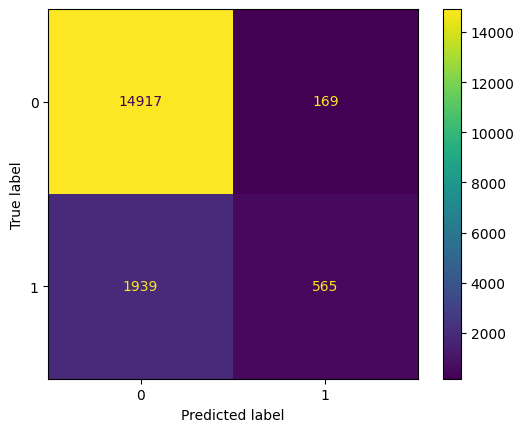

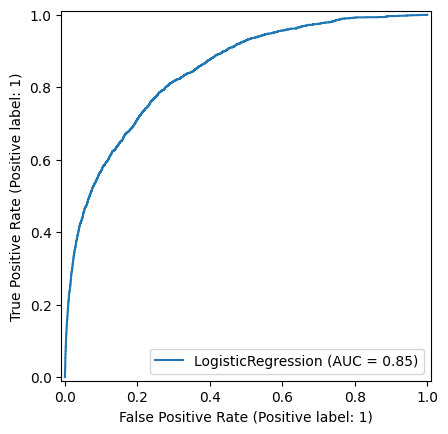

In [8]:
#LR

# Present a comparison of actual vs predicted status in a data frame
Comparison_df = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred})

# Display the comparison dataframe
display(Comparison_df)

# Bring in the tool to check model accuracy
from sklearn.metrics import accuracy_score

# Calculate the accuracy on the test data
accuracy = accuracy_score(y_test, y_pred)

# Present the calculated accuracy score
print ("The accuracy is: ", accuracy)

# Bring in the tools to make a confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels = logreg.classes_)

# Set up the visual chart for the matrix
disp = ConfusionMatrixDisplay(cm, display_labels = logreg.classes_)

# Plot the confusion matrix
disp.plot()

# Load the Python code block to produce the classification report
from sklearn.metrics import classification_report

# Print the classification report with combined performance metrics
print(classification_report(y_test, y_pred))

# Load the package to plot the ROC curve
from sklearn.metrics import RocCurveDisplay

# Display the Area Under the Receiver Operating Characteristic (ROC) Curve
roc_disp = RocCurveDisplay.from_estimator(logreg, X_test, y_test)

**Reused from: Code Reuse Session 2 (Prompts 20, 21, 22, 23)**

In [9]:
# Bring in the K-Nearest Neighbors model
from sklearn.neighbors import KNeighborsClassifier

# Set up the model to look at the 5 closest neighbors
knn = KNeighborsClassifier(n_neighbors = 5)

# Train the KNN model using our training data
knn.fit(X_train,y_train)

# Use the trained KNN model to predict loan approvals for our test group
y_pred = knn.predict(X_test)

**Reused from: Code Reuse Session 2 (Prompts 14, 16, 17, 18, 19)**

,Actual,Predicted
18011,0,0
36953,0,0
17735,0,0
54723,0,0
54187,0,0
...,...,...
36194,0,0
15588,0,0
14120,0,0
39329,0,0


The accuracy is:  0.8817509948834565
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     15086
           1       0.64      0.38      0.48      2504

    accuracy                           0.88     17590
   macro avg       0.77      0.67      0.71     17590
weighted avg       0.87      0.88      0.87     17590



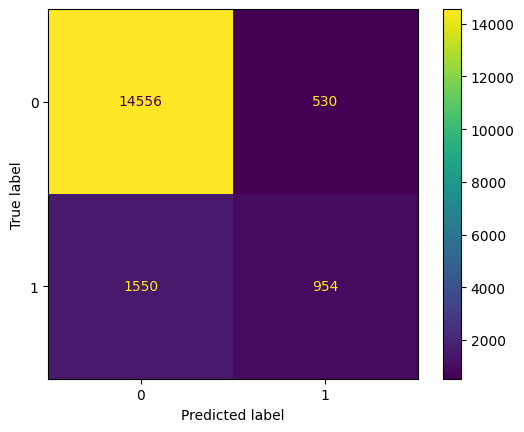

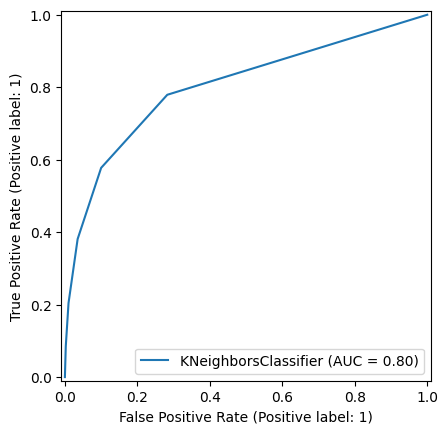

In [10]:
#KNN

# Create a table to compare the real results against the model's guesses
Comparison_df = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred})

# Show the comparison table
display(Comparison_df)

# Bring in the tool to check model accuracy
from sklearn.metrics import accuracy_score

# Calculate the accuracy on the test data
accuracy = accuracy_score(y_test, y_pred)

# Print the calculated accuracy score
print ("The accuracy is: ", accuracy)

# Bring in the tools to make a confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix for the KNN model
cm = confusion_matrix(y_test, y_pred, labels = knn.classes_)

# Set up the visual chart for the matrix
disp = ConfusionMatrixDisplay(cm, display_labels = knn.classes_)

# Draw the confusion matrix
disp.plot()

# Bring in the tool for the detailed classification report
from sklearn.metrics import classification_report

# Print the report to check Precision, Recall, and F1-scores
print(classification_report(y_test, y_pred))

# Bring in the tool to plot the ROC curve
from sklearn.metrics import RocCurveDisplay

# Show the ROC curve to see how well the KNN model separates the categories
roc_disp = RocCurveDisplay.from_estimator(knn, X_test, y_test)

**Reused from: Code Reuse Session 2 (Prompt 27)**

In [11]:
# Bring in the Naive Bayes model
from sklearn.naive_bayes import GaussianNB

# Set up the Naive Bayes model
nb = GaussianNB()

# Train the model using the training data
nb.fit(X_train, y_train)

# Use the model to predict loan approvals for the test group
y_pred = nb.predict(X_test)

**Reused from: Code Reuse Session 2 (Prompts 14, 16, 17, 18, 19)**

,Actual,Predicted
18011,0,0
36953,0,0
17735,0,0
54723,0,0
54187,0,0
...,...,...
36194,0,0
15588,0,0
14120,0,0
39329,0,0


The accuracy is:  0.8401364411597498
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     15086
           1       0.44      0.44      0.44      2504

    accuracy                           0.84     17590
   macro avg       0.67      0.67      0.67     17590
weighted avg       0.84      0.84      0.84     17590



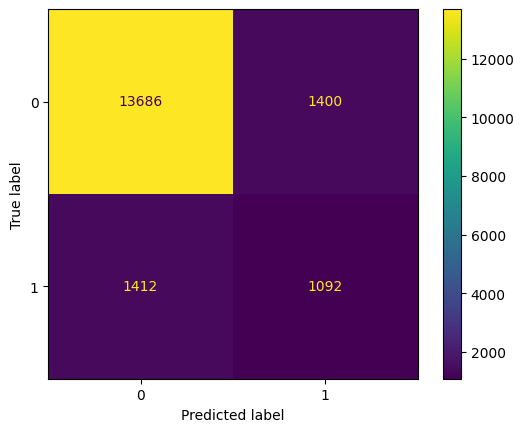

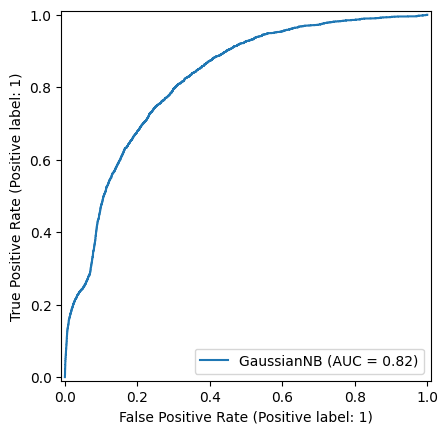

In [12]:
#NB

# Create a table to compare the real results against the model's guesses
Comparison_df = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred})

# Show the comparison table
display(Comparison_df)

# Bring in the tool to check model accuracy
from sklearn.metrics import accuracy_score

# Calculate the accuracy on the test data
accuracy = accuracy_score(y_test, y_pred)

# Print the calculated accuracy score
print ("The accuracy is: ", accuracy)

# Bring in the tools to make a confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix for the Naive Bayes model
cm = confusion_matrix(y_test, y_pred, labels = nb.classes_)

# Set up the visual chart for the matrix
disp = ConfusionMatrixDisplay(cm, display_labels = nb.classes_)

# Draw the confusion matrix
disp.plot()

# Bring in the tool for the detailed classification report
from sklearn.metrics import classification_report

# Print the report to check Precision, Recall, and F1-scores
print(classification_report(y_test, y_pred))

# Bring in the tool to plot the ROC curve
from sklearn.metrics import RocCurveDisplay

# Show the ROC curve to see how well the Naive Bayes model separates the categories
roc_disp = RocCurveDisplay.from_estimator(nb, X_test, y_test)

**Reused from: Code Reuse Session 2 (Prompts 24, 25, 26)**

In [13]:
# Bring in the tool to test different model settings
from sklearn.model_selection import GridSearchCV

# Create a menu of different settings to test for the KNN model
param_grid = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}

# Set up the search to test every combination using cross-validation
knn_gscv = GridSearchCV(knn, param_grid, cv = 5)

# Run the search to find the best possible settings
knn_gscv.fit(X_train, y_train)

# Print the winning configuration
print(knn_gscv.best_params_)

# Use the optimized model to predict loan approvals for the test group
y_pred = knn_gscv.predict(X_test)

{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}


**Reused from: Code Reuse Session 2 (Prompts 14, 16, 17, 18, 19)**

,Actual,Predicted
18011,0,0
36953,0,0
17735,0,0
54723,0,0
54187,0,0
...,...,...
36194,0,0
15588,0,0
14120,0,0
39329,0,0


The accuracy is:  0.8910744741330301
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     15086
           1       0.72      0.39      0.50      2504

    accuracy                           0.89     17590
   macro avg       0.81      0.68      0.72     17590
weighted avg       0.88      0.89      0.88     17590



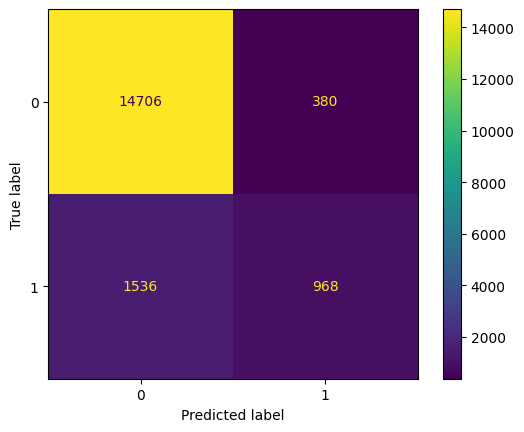

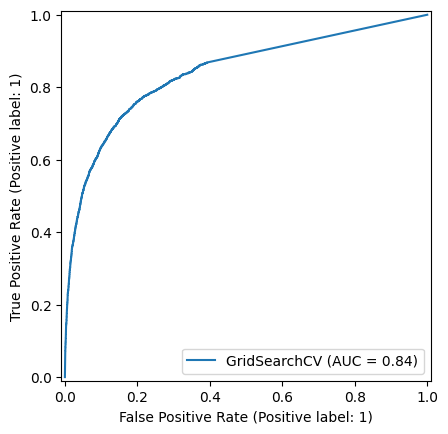

In [14]:
# Create a table to compare the real results against the model's guesses
Comparison_df = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred})

# Show the comparison table
display(Comparison_df)

# Bring in the tool to check model accuracy
from sklearn.metrics import accuracy_score

# Calculate the accuracy on the test data
accuracy = accuracy_score(y_test, y_pred)

# Print the calculated accuracy score
print ("The accuracy is: ", accuracy)

# Bring in the tools to make a confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix for the tuned KNN model
cm = confusion_matrix(y_test, y_pred, labels = knn_gscv.classes_)

# Set up the visual chart for the matrix
disp = ConfusionMatrixDisplay(cm, display_labels = knn_gscv.classes_)

# Draw the confusion matrix
disp.plot()

# Bring in the tool for the detailed classification report
from sklearn.metrics import classification_report

# Print the report to check Precision, Recall, and F1-scores
print(classification_report(y_test, y_pred))

# Bring in the tool to plot the ROC curve
from sklearn.metrics import RocCurveDisplay

# Show the ROC curve to see how well the tuned KNN model separates the categories
roc_disp = RocCurveDisplay.from_estimator(knn_gscv, X_test, y_test)